# 📘 Risk Analysis — Winter Semester 2025/2026
## Tutorial 8: Normal, Log-normal and Multi-normal distributions

**Supervisor:** Dr. Daniel Straub  
**Conducted by:** Milad Cheraghzade  
**Date:** December 11th, 2025  
**Time:** 15:00–16:00  
**Location:** TUM, Room N 1070  

---


In [ ]:
import numpy as np
from scipy.stats import norm

###############################################################################
# Oil Reservoir Problem
#
# Volume:
#       V = W * D * H
#
# W, D, H are independent lognormal random variables.
#
# If X ~ Lognormal(mu_lnX, sigma_lnX^2),
# then:
#   E[X]        = exp(mu_lnX + 0.5 * sigma_lnX^2)
#   Var[X]      = exp(2*mu_lnX + sigma_lnX^2) * (exp(sigma_lnX^2) - 1)
#
# Given:
#   E[W] = 1000,  sigma_W = 200
#   E[D] = 3000,  sigma_D = 200
#   E[H] = 500,   sigma_H = 200
#
# Goal:
#   Compute P(V < 10^9)
###############################################################################


def lognormal_mu_sigma(mean, sd):
    """
    Convert mean and standard deviation of lognormal X
    into parameters of ln(X) ~ Normal(mu, sigma^2).

    For a lognormal variable X:
        sigma_ln^2 = ln(1 + (sd/mean)^2)
        mu_ln      = ln(mean) - 0.5 * sigma_ln^2

    Returns:
        mu_ln, sigma_ln
    """
    sigma_ln = np.sqrt(np.log(1 + (sd / mean) ** 2))
    mu_ln = np.log(mean) - 0.5 * sigma_ln ** 2
    return mu_ln, sigma_ln


# -----------------------------------------------------------------------------
# 1. Given means and standard deviations of W, D, H
# -----------------------------------------------------------------------------
mW, sW = 1000, 200      # width
mD, sD = 3000, 200      # depth
mH, sH = 500,  200       # height

# -----------------------------------------------------------------------------
# 2. Compute (mu_ln, sigma_ln) for W, D, H
# -----------------------------------------------------------------------------
mu_lnW, s_lnW = lognormal_mu_sigma(mW, sW)
mu_lnD, s_lnD = lognormal_mu_sigma(mD, sD)
mu_lnH, s_lnH = lognormal_mu_sigma(mH, sH)

print("ln(W) parameters :", mu_lnW, s_lnW)
print("ln(D) parameters :", mu_lnD, s_lnD)
print("ln(H) parameters :", mu_lnH, s_lnH)


# -----------------------------------------------------------------------------
# 3. Since ln(V) = ln(W) + ln(D) + ln(H),
#    and the variables are independent normals:
#
#       mu_lnV    = mu_lnW + mu_lnD + mu_lnH
#       sigma_lnV = sqrt( s_lnW^2 + s_lnD^2 + s_lnH^2 )
#
# Thus V ~ Lognormal(mu_lnV, sigma_lnV^2).
# -----------------------------------------------------------------------------
mu_lnV = mu_lnW + mu_lnD + mu_lnH
s_lnV = np.sqrt(s_lnW**2 + s_lnD**2 + s_lnH**2)

print("ln(V) mean  :", mu_lnV)
print("ln(V) stdev :", s_lnV)


# -----------------------------------------------------------------------------
# 4. Compute probability P(V < 10^9)
#
#    P(V < U) = P( ln(V) < ln(U) )
#             = Φ( (ln(U) - mu_lnV) / sigma_lnV )
#
# where Φ is the standard normal CDF.
# -----------------------------------------------------------------------------
U = 1e9        # threshold volume

z = (np.log(U) - mu_lnV) / s_lnV
P = norm.cdf(z)

print("\nProbability P(V < 10^9) =", P)




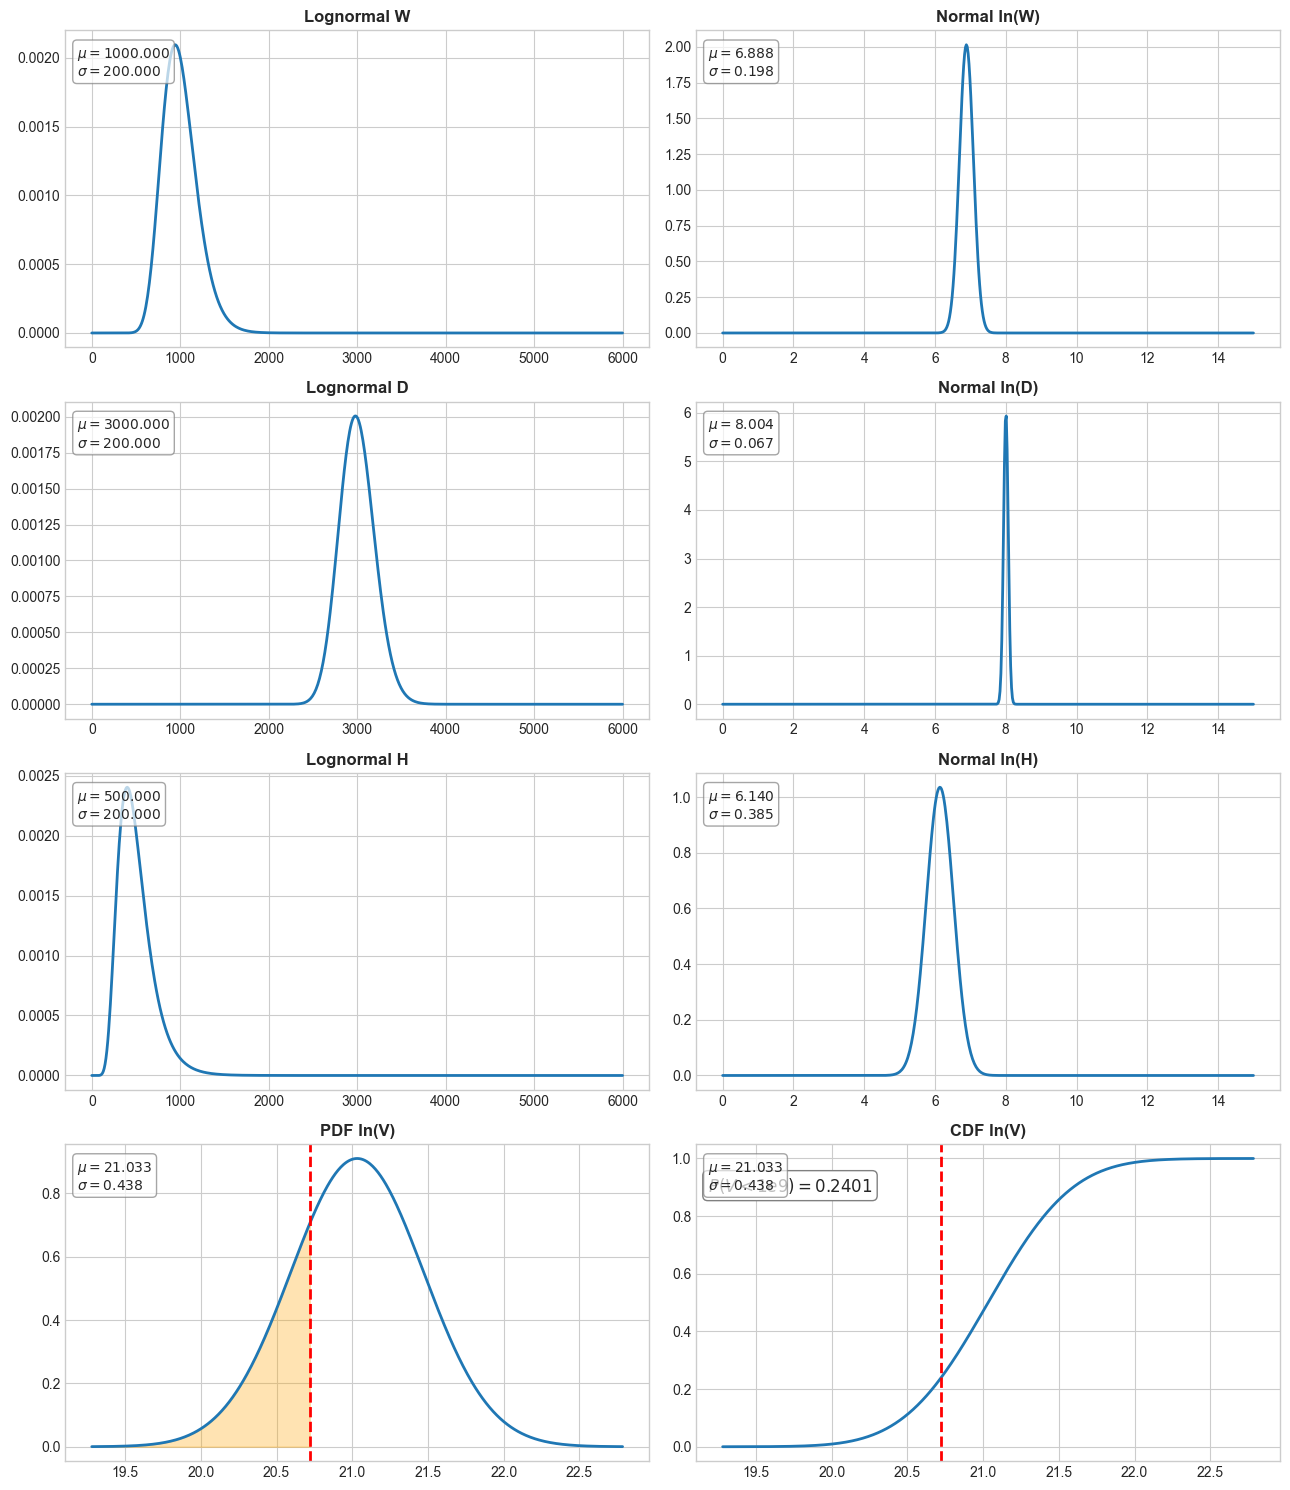

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import lognorm, norm

# Parameters
mW, sW = 1000, 200
mD, sD = 3000, 200
mH, sH = 500,  200

def lognormal_mu_sigma(mean, sd):
    sigma_ln = np.sqrt(np.log(1 + (sd / mean) ** 2))
    mu_ln = np.log(mean) - 0.5 * sigma_ln**2
    return mu_ln, sigma_ln

# Convert
mu_lnW, s_lnW = lognormal_mu_sigma(mW, sW)
mu_lnD, s_lnD = lognormal_mu_sigma(mD, sD)
mu_lnH, s_lnH = lognormal_mu_sigma(mH, sH)

# ln(V)
mu_lnV = mu_lnW + mu_lnD + mu_lnH
s_lnV = np.sqrt(s_lnW**2 + s_lnD**2 + s_lnH**2)

# Threshold
U = 1e9
z = (np.log(U) - mu_lnV) / s_lnV
P = norm.cdf(z)

# Plot ranges
x_log = np.linspace(0, 6000, 600)
x_norm = np.linspace(0, 15, 600)
x_lnV = np.linspace(mu_lnV - 4*s_lnV, mu_lnV + 4*s_lnV, 600)

# Nice style
plt.style.use("seaborn-v0_8-whitegrid")

fig, axes = plt.subplots(4, 2, figsize=(13, 15))

def annotate(ax, mu, sd, title):
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.text(
        0.02, 0.95,
        f"$\\mu={mu:.3f}$\n$\\sigma={sd:.3f}$",
        transform=ax.transAxes,
        fontsize=10,
        verticalalignment="top",
        bbox=dict(boxstyle="round", fc="white", ec="gray", alpha=0.7)
    )

# Row 1: W
axes[0,0].plot(x_log, lognorm.pdf(x_log, s_lnW, scale=np.exp(mu_lnW)), linewidth=2)
annotate(axes[0,0], np.exp(mu_lnW + 0.5*s_lnW**2), np.sqrt((np.exp(s_lnW**2)-1)*np.exp(2*mu_lnW+s_lnW**2)), "Lognormal W")

axes[0,1].plot(x_norm, norm.pdf(x_norm, mu_lnW, s_lnW), linewidth=2)
annotate(axes[0,1], mu_lnW, s_lnW, "Normal ln(W)")

# Row 2: D
axes[1,0].plot(x_log, lognorm.pdf(x_log, s_lnD, scale=np.exp(mu_lnD)), linewidth=2)
annotate(axes[1,0], np.exp(mu_lnD + 0.5*s_lnD**2), np.sqrt((np.exp(s_lnD**2)-1)*np.exp(2*mu_lnD+s_lnD**2)), "Lognormal D")

axes[1,1].plot(x_norm, norm.pdf(x_norm, mu_lnD, s_lnD), linewidth=2)
annotate(axes[1,1], mu_lnD, s_lnD, "Normal ln(D)")

# Row 3: H
axes[2,0].plot(x_log, lognorm.pdf(x_log, s_lnH, scale=np.exp(mu_lnH)), linewidth=2)
annotate(axes[2,0], np.exp(mu_lnH + 0.5*s_lnH**2), np.sqrt((np.exp(s_lnH**2)-1)*np.exp(2*mu_lnH+s_lnH**2)), "Lognormal H")

axes[2,1].plot(x_norm, norm.pdf(x_norm, mu_lnH, s_lnH), linewidth=2)
annotate(axes[2,1], mu_lnH, s_lnH, "Normal ln(H)")

# Row 4: ln(V)
axes[3,0].plot(x_lnV, norm.pdf(x_lnV, mu_lnV, s_lnV), linewidth=2)
axes[3,0].axvline(np.log(U), color='red', linestyle='--', linewidth=2)
annotate(axes[3,0], mu_lnV, s_lnV, "PDF ln(V)")
axes[3,0].fill_between(x_lnV, norm.pdf(x_lnV, mu_lnV, s_lnV),
                       where=(x_lnV < np.log(U)), color='orange', alpha=0.3)

axes[3,1].plot(x_lnV, norm.cdf(x_lnV, mu_lnV, s_lnV), linewidth=2)
axes[3,1].axvline(np.log(U), color='red', linestyle='--', linewidth=2)
axes[3,1].text(
    0.02, 0.85,
    f"$P(V<1e9)={P:.4f}$",
    transform=axes[3,1].transAxes,
    fontsize=12,
    bbox=dict(boxstyle="round", fc="white", ec="gray")
)
annotate(axes[3,1], mu_lnV, s_lnV, "CDF ln(V)")

plt.tight_layout()
plt.show()


In [8]:
import numpy as np
from scipy.stats import multivariate_normal, norm


# -----------------------------------------------------------------------------
# Mean and standard deviation of the concentration at each location.
# Each concentration is modeled as:
#       C_i ~ Normal(μ, σ^2)
# with μ = 1e-3 and σ = 3e-4.
# -----------------------------------------------------------------------------
mu = 1e-3
MX = np.array([mu, mu, mu])

sigma = 3e-4
var = sigma**2

DX = np.diag([sigma, sigma, sigma])

# -----------------------------------------------------------------------------
# Spatial dependence among locations A, B, C is represented by the correlation
# matrix RXX, which captures how the similarity between concentrations decreases
# with distance. This matrix will later be converted into a covariance matrix.
# -----------------------------------------------------------------------------
RXX = np.array([
    [1.00, 0.39, 0.51],
    [0.39, 1.00, 0.51],
    [0.51, 0.51, 1.00]
])


# -----------------------------------------------------------------------------
# (a) Covariance matrix Σ = D_X RXX D_X
#
# The covariance structure of the multivariate normal distribution is constructed
# by scaling the correlation matrix with the marginal standard deviations.
# This yields:
#       Σ_ij = σ_i σ_j R_ij
# -----------------------------------------------------------------------------
CXX = DX @ RXX @ DX
print("Covariance matrix Σ:\n", CXX)


# -----------------------------------------------------------------------------
# (b) Probability that all concentrations are ≤ 2e-3.
#
# The vector of concentrations X = (C_A, C_B, C_C) follows:
#       X ~ MVN(MX, CXX)
#
# Therefore:
#   P(C_A ≤ t, C_B ≤ t, C_C ≤ t)
# is computed by evaluating the trivariate normal CDF at (t, t, t).
# -----------------------------------------------------------------------------
t = 2e-3
threshold = np.array([t, t, t])

mvn = multivariate_normal(mean=MX, cov=CXX)
Pr_b = mvn.cdf(threshold)

print("\nP(all ≤ 2e-3) =", Pr_b)


# -----------------------------------------------------------------------------
# (c) Conditional distribution of C given observed values at A and B.
#
# Partition the variables as:
#       a = C       (unobserved)
#       z = (C_A, C_B)  (observed)
#
# For a multivariate normal distribution, the conditional distribution is:
#
#   μ_{a|z} = μ_a + Σ_az Σ_zz^{-1} (z_obs - μ_z)
#   Σ_{a|z} = Σ_aa - Σ_az Σ_zz^{-1} Σ_za
#
# This updates both mean and variance based on the measurements at A and B.
# -----------------------------------------------------------------------------
Ma = MX[2]
Mz = MX[:2]

z_obs = np.array([1e-3, 1.2e-3])

Sigma_aa = CXX[2, 2]
Sigma_zz = CXX[:2, :2]
Sigma_az = CXX[2, :2].reshape(1, 2)
Sigma_za = Sigma_az.T

# Compute conditional mean of C
Mu_cond = Ma + Sigma_az @ np.linalg.inv(Sigma_zz) @ (z_obs - Mz)

print("\nConditional mean at C =", Mu_cond)

# Compute conditional variance of C
Sigma_cond = Sigma_aa - Sigma_az @ np.linalg.inv(Sigma_zz) @ Sigma_za

print("Conditional variance at C =", Sigma_cond)


# -----------------------------------------------------------------------------
# Probability that C ≤ 2e-3 given the observations.
#
# Since C | (A,B) is normally distributed:
#       C | A,B  ~ Normal( μ_{C|A,B} , Σ_{C|A,B} )
#
# we compute:
#       P(C ≤ t | A,B) = Φ( (t - μ_{C|A,B}) / sqrt(Σ_{C|A,B}) ).
# -----------------------------------------------------------------------------
Pr_c = norm.cdf((2e-3 - Mu_cond) / np.sqrt(Sigma_cond))

print("\nP(C ≤ 2e-3 | A, B) =", Pr_c)


Covariance matrix Σ:
 [[9.00e-08 3.51e-08 4.59e-08]
 [3.51e-08 9.00e-08 4.59e-08]
 [4.59e-08 4.59e-08 9.00e-08]]

P(all ≤ 2e-3) = 0.998760517724316

Conditional mean at C = [0.00107338]
Conditional variance at C = [[5.63179856e-08]]

P(C ≤ 2e-3 | A, B) = [[0.99995281]]


In [5]:
import numpy as np
from scipy.stats import multivariate_normal
from scipy.integrate import nquad

# Example MX and CXX (user must replace with actual values if needed)
MX = np.array([1e-3, 1e-3, 1e-3])
CXX = np.array([
    [9e-8, 3.51e-8, 4.59e-8],
    [3.51e-8, 9e-8, 4.59e-8],
    [4.59e-8, 4.59e-8, 9e-8]
])

t = 2e-3
threshold = np.array([t, t, t])

# PDF function
mvn = multivariate_normal(mean=MX, cov=CXX)
pdf = lambda x3, x2, x1: mvn.pdf([x1, x2, x3])

# Limits: integrate x1 from -inf to t, x2 from -inf to t, x3 from -inf to t
res, err = nquad(pdf, [[-np.inf, t], [-np.inf, t], [-np.inf, t]])

Pr_cdf_direct = mvn.cdf(threshold)

res, err, Pr_cdf_direct


(0.9987245412572374, 0.02728651002313942, np.float64(0.9987474729108253))

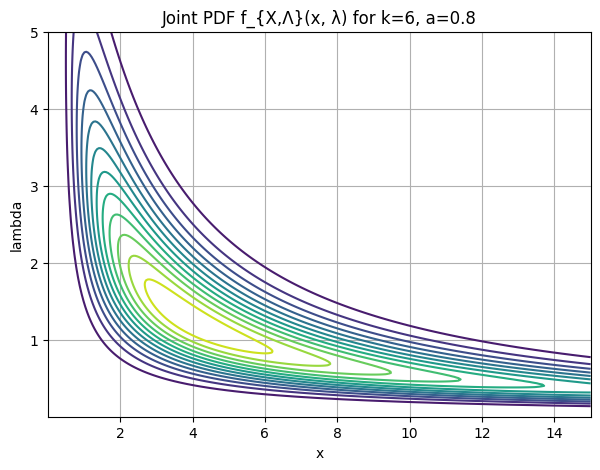

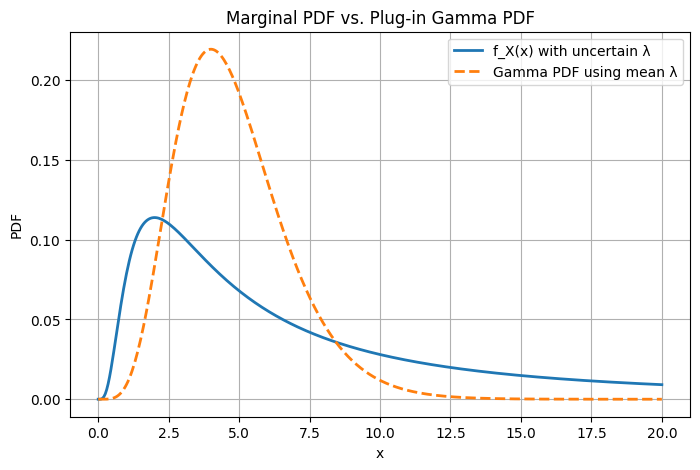

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import gamma

# -----------------------------------------------------------------------------
# Parameters for the problem:
#   k = shape parameter of the gamma distribution
#   a = rate parameter of the exponential prior on Lambda (mean = 1/a)
# -----------------------------------------------------------------------------
k = 6
a = 0.8

# -----------------------------------------------------------------------------
# (a) Joint PDF of X and Lambda:
#
#   f_{X,Λ}(x, λ) = (a * λ^k * x^{k-1} / Γ(k)) * exp[-λ(x + a)]
#
# This expression is used to generate the contour plot.
# -----------------------------------------------------------------------------
def joint_pdf(x, lam):
    return a * (lam**k) * (x**(k-1)) * np.exp(-lam * (x + a)) / gamma(k)


# Grid for plotting
x_vals = np.linspace(0.01, 15, 300)
lam_vals = np.linspace(0.01, 5, 300)
X, L = np.meshgrid(x_vals, lam_vals)
Z = joint_pdf(X, L)

plt.figure(figsize=(7, 5))
plt.contour(X, L, Z, levels=12)
plt.xlabel("x")
plt.ylabel("lambda")
plt.title("Joint PDF f_{X,Λ}(x, λ) for k=6, a=0.8")
plt.grid(True)
plt.show()

# -----------------------------------------------------------------------------
# (b) Marginal PDF of X with uncertain Lambda:
#
#   f_X(x) = [a * k * x^{k-1}] / (x + a)^{k+1}
#
# -----------------------------------------------------------------------------
def marginal_pdf(x):
    return a * k * (x**(k-1)) / ((x + a)**(k+1))


# -----------------------------------------------------------------------------
# (c) Plug-in gamma PDF using only the mean of Lambda:
#
#   E[Λ] = 1/a
#
#   f_plug(x) = [(1/a)^k * x^{k-1} / Γ(k)] * exp[-x/a]
#
# This ignores uncertainty in Lambda.
# -----------------------------------------------------------------------------
lam_mean = 1 / a

def gamma_plug(x):
    return (lam_mean**k) * (x**(k-1)) * np.exp(-lam_mean * x) / gamma(k)


# x-domain for plotting both PDFs
x_plot = np.linspace(0, 20, 400)

plt.figure(figsize=(8, 5))
plt.plot(x_plot, marginal_pdf(x_plot), label="f_X(x) with uncertain λ", linewidth=2)
plt.plot(x_plot, gamma_plug(x_plot), "--", label="Gamma PDF using mean λ", linewidth=2)
plt.xlabel("x")
plt.ylabel("PDF")
plt.title("Marginal PDF vs. Plug-in Gamma PDF")
plt.grid(True)
plt.legend()
plt.show()
